### Zigbang 원룸 매물 데이터 수집

In [1]:
import requests
import pandas as pd

#### Process
    - 동이름으로 위도 경도 구하기
    - 위도 경도로 geohash 알아내기
    - geohash로 매물 아이디 가져오기
    - 매물 아이디로 매물 정보 가져오기

#### 1. 동이름으로 위도 경도 구하기

In [5]:
addr = '망원동'
url = f'https://apis.zigbang.com/v2/search?leaseYn=N&q={addr}&serviceType=원룸'
response = requests.get(url)

data = response.json()['items'][0]
# lat(위도), lng(경도)
lat, lng = data['lat'], data['lng']
lat, lng

(37.556785583496094, 126.9013442993164)

In [17]:
data

{'id': 4002,
 'type': 'address',
 'name': '망원동',
 'hint': '',
 'description': '서울특별시 마포구 망원동',
 'lat': 37.556785583496094,
 'lng': 126.9013442993164,
 'zoom': 5,
 'polygon': [],
 '_score': None,
 '_source': {'name_length': 3,
  'local1': '서울시',
  'local2': '마포구',
  'local3': '망원동',
  'web_level': 15,
  'web_lat': 37.556785583496094,
  'web_lng': 126.9013442993164,
  'app_level': 15,
  'app_lat': 37.556785583496094,
  'app_lng': 126.9013442993164,
  '법정동코드': '1144012300'},
 'zoom_level': {'google': 15, 'daum': 4},
 'zoom_level_v2': {'app': 5, 'web': 4}}

#### 2. 위도 경도로 geohash 알아내기
* geohash란?   
공간 상의 좌표값을(GPS 위경도 등) 일정한 값으로 치환하는 작업을 뜻한다.


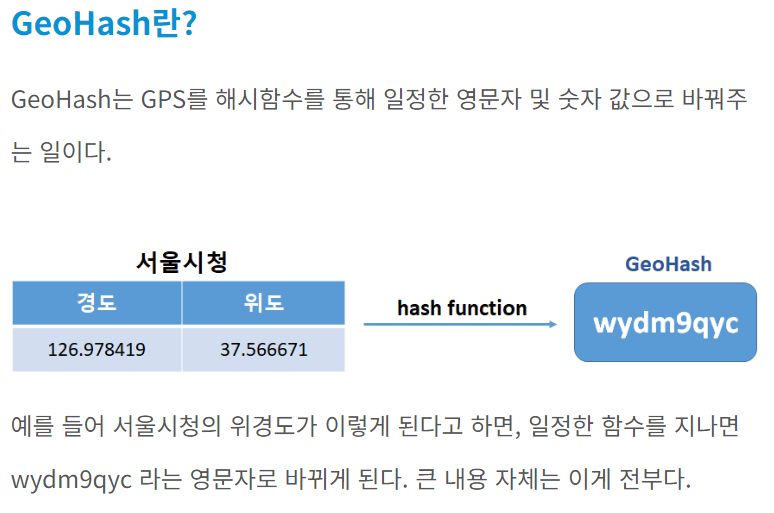

In [11]:
# !pip install geohash2

In [9]:
import geohash2

In [15]:
geohash = geohash2.encode(lat, lng, precision=5)  # precision=5 -> 5개의 글자가 나온다.
geohash

'wydjx'

#### 3. geohash로 매물 아이디 가져오기

In [32]:
url = f'https://apis.zigbang.com/v2/items/oneroom?geohash={geohash}&depositMin=0&rentMin=0&salesTypes[0]=전세&salesTypes[1]=월세&domain=zigbang&checkAnyItemWithoutFilter=true'
response = requests.get(url)
item_ids = [data['itemId'] for data in response.json()['items']]
len(item_ids), item_ids[:5]

(381, [42196796, 42078100, 42149571, 42184803, 42204685])

#### 4. 매물 아이디로 매물 정보 가져오기
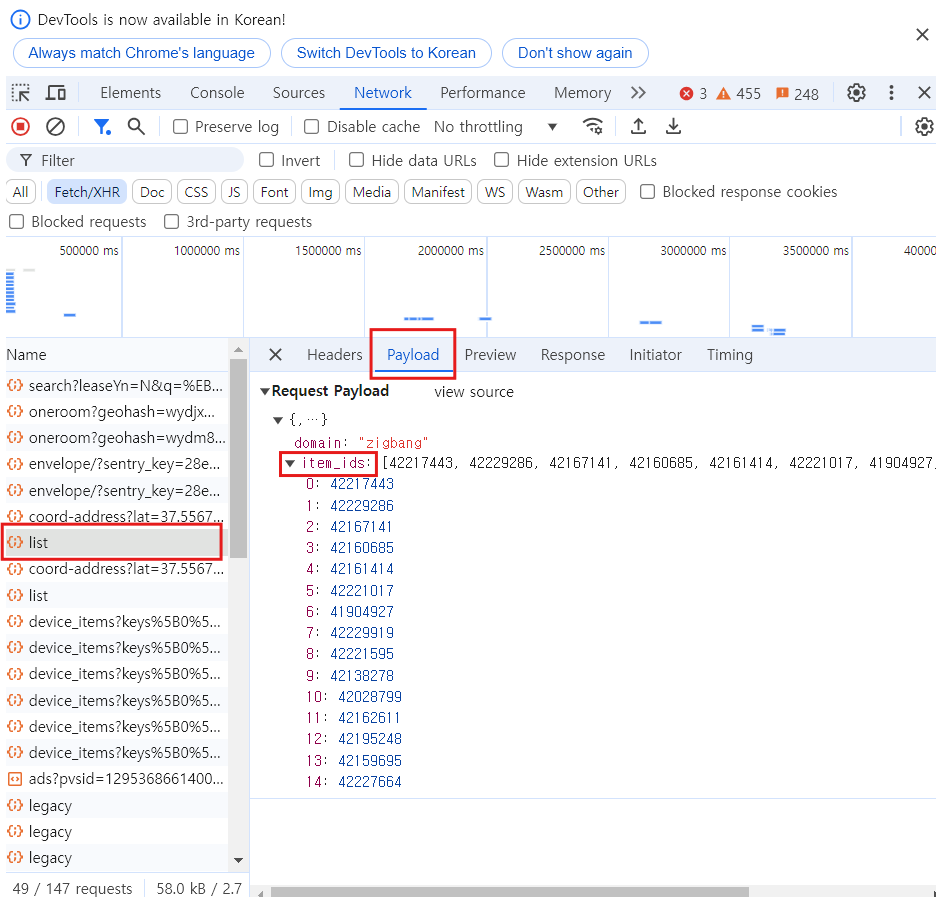

In [34]:
url = 'https://apis.zigbang.com/v2/items/list'
params = {'domain': "zigbang", 'item_ids': item_ids}
response = requests.post(url, params)
response

<Response [200]>

In [36]:
# 데이터를 다 가지고 왔다.
response.text

'{"items":[{"item_id":42196796,"section_type":null,"images_thumbnail":"https://ic.zigbang.com/ic/items/42196796/1.jpg","sales_type":"월세","sales_title":"월세","deposit":1000,"rent":50,"size_m2":19.83,"공급면적":{"m2":19.83,"p":"6"},"전용면적":{"m2":19.83,"p":"6"},"계약면적":null,"room_type_title":null,"floor":"3","floor_string":"3","building_floor":"9","title":"당산 최고 컨디션 가성비 분리형 안심 원룸","is_first_movein":null,"room_type":"02","status":true,"tags":["추천"],"service_type":"원룸","random_location":{"lat":37.5293352247656,"lng":126.900107648411},"location":{"lat":37.5293352247656,"lng":126.900107648411},"manage_cost":"9","reg_date":"2024-09-14T11:51:22+09:00","is_new":false,"addressOrigin":{"local1":"서울시","local2":"영등포구","local3":"당산동4가","local4":"","fullText":"서울시 영등포구 당산동4가","localText":"영등포구 당산동4가"},"action":{"isRead":false,"readAt":null,"isInquired":false,"inquiredAt":null,"isRewarded":false,"rewardedAt":null,"isReported":false,"reportedAt":null,"isChecked":false,"checkedAt":null,"isZzim":false},"contract

In [51]:
pd.options.display.max_columns = 40

In [69]:
# parsing
data = response.json()['items']
df = pd.DataFrame(data)
df = df[df['address1'].str.contains(addr)].reset_index(drop=True)  # 이것을 넣어야 '망원동'만 출력된다.
df = df[['item_id', 'sales_title', 'deposit', 'rent', 'size_m2', 'floor', 'building_floor', 'title',
'manage_cost', 'address1']]

df.tail(1)

,item_id,sales_title,deposit,rent,size_m2,floor,building_floor,title,manage_cost,address1
20,42232358,월세,300,73,17.0,3,3,"v망원한강코앞,화이트톤방,깔끔한 화장실,채광,조용한주택가",8,서울시 마포구 망원동


In [41]:
df.columns

Index(['item_id', 'section_type', 'images_thumbnail', 'sales_type',
       'sales_title', 'deposit', 'rent', 'size_m2', '공급면적', '전용면적', '계약면적',
       'room_type_title', 'floor', 'floor_string', 'building_floor', 'title',
       'is_first_movein', 'room_type', 'status', 'tags', 'service_type',
       'random_location', 'location', 'manage_cost', 'reg_date', 'is_new',
       'addressOrigin', 'action', 'contract', 'address', 'is_zzim', 'address1',
       'address2', 'address3', 'item_bm_type', 'isCleanLessor', 'zikim'],
      dtype='object')

In [59]:
# 5. function
def oneroom(addr):

    url = f'https://apis.zigbang.com/v2/search?leaseYn=N&q={addr}&serviceType=원룸'
    response = requests.get(url)
    data = response.json()['items'][0]
    lat, lng = data['lat'], data['lng']
    
    geohash = geohash2.encode(lat, lng, precision=5)
    
    url = f'https://apis.zigbang.com/v2/items/oneroom?geohash={geohash}&depositMin=0&rentMin=0&salesTypes[0]=전세&salesTypes[1]=월세&domain=zigbang&checkAnyItemWithoutFilter=true'
    response = requests.get(url)
    item_ids = [data['itemId'] for data in response.json()['items']]
    
    url = 'https://apis.zigbang.com/v2/items/list'
    params = {'domain': "zigbang", 'item_ids': item_ids[:900]}
    response = requests.post(url, params)
    data = response.json()['items']
    df = pd.DataFrame(data)
    df = df[df['address1'].str.contains(addr)].reset_index(drop=True)
    
    return df[['item_id', 'sales_title', 'deposit', 'rent', 'size_m2', 'floor', 'building_floor', 'title',
    'manage_cost', 'address1']]

In [61]:
df = oneroom('개포동')
df.tail(2)

,item_id,sales_title,deposit,rent,size_m2,floor,building_floor,title,manage_cost,address1
51,41718888,전세,33000,0,37.79,3,4,"깔끔하고 심플한 투룸, 주차 가능, 풀옵션 완비",20,서울시 강남구 개포동
52,40818078,전세,38000,0,71.64,3,3,"깨끗하고 넓은 공간 쓰리룸, 즉시 입주 가능, 주차 가능",0,서울시 강남구 개포동
